# Infinite Series Summation using Euler–Maclaurin and Euler–Boole Tail Approximations

This notebook demonstrates the computation of various infinite series sums using tail approximations. Each example is run in its own cell so you can capture the output (both numerical and plots) for your Thesis.

In [1]:
# Install and update required packages
import Pkg
Pkg.activate(".")
Pkg.instantiate()

# Add/update required packages
Pkg.add("SymPy")
Pkg.add("Plots")
Pkg.add("Printf")
Pkg.add("SpecialFunctions")
Pkg.update()

  Activating project at `~/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation`
   Resolving package versions...
  No Changes to `~/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/Project.toml`
  No Changes to `~/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/Manifest.toml`
   Resolving package versions...
  No Changes to `~/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/Project.toml`
  No Changes to `~/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/Manifest.toml`
   Resolving package versions...
  No Changes to `~/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/Project.toml`
  No Changes to `~/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/Manifest.toml`
   Resolving package versions...
  No Changes to `~/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/Project.toml`
  No Changes to `~/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/Manifest.toml`
    Updating registry at `~/.julia/registries/General.toml`

## Module Definition: Analytictail

The following cell defines the module `Analytictail` which contains all functions needed for computing the infinite series sums using Euler–Maclaurin (for non‐alternating series) and Euler–Boole (for alternating series) tail approximations. Note that we export the symbols `run_example` and `x_` so they can be used directly from the Main module.

In [2]:
module Analytictail

using SymPy
using Plots
using Printf
using SpecialFunctions  # For coth, etc.

export run_example, sum_infinite_series, plot_error_vs_m, x_

##########################################################
# 1) Setup
##########################################################
setprecision(256)  # Very high precision for demonstration
gr()

# Partial-sum cutoffs
const Kset = [0, 1, 2, 3, 4]
# Max correction terms
const m_max = 30

# We'll store Bernoulli / Euler polynomials in caches
const bernoulliCache = Dict{Int, Vector{Rational{BigInt}}}()
const eulerPolyCache = Dict{Tuple{Int, Float64}, Dict{Int, Float64}}()

##########################################################
# 2) Bernoulli numbers (caching)
##########################################################
function BernoulliListCached(n::Int)::Vector{Rational{BigInt}}
    if haskey(bernoulliCache, n)
        return bernoulliCache[n]
    end
    A = Vector{Rational{BigInt}}(undef, n+1)
    B = similar(A)
    for mm in 0:n
        A[mm+1] = 1 // (mm+1)
        for j in mm:-1:1
            A[j] = j*(A[j]-A[j+1])
        end
        B[mm+1] = A[1]
    end
    bernoulliCache[n] = B
    return B
end

##########################################################
# 3) Euler polynomials (for Euler–Boole)
##########################################################
function euler_polynomials_cached(max_n::Int, x_val::Float64)::Dict{Int, Float64}
    key = (max_n, x_val)
    if haskey(eulerPolyCache, key)
        return eulerPolyCache[key]
    end

    t = SymPy.symbols("t")
    expr = (2*SymPy.exp(x_val*t)) / (SymPy.exp(t)+1)
    out = Dict{Int, Float64}()
    for n in 0:max_n
        try
            ser = expr.series(t, 0, n+1).expand()
            coeff_n = factorial(big(n))*ser.coeff(t,n)
            out[n] = float(coeff_n)
        catch
            @warn "Failed Euler poly E_$n($x_val)"
            out[n] = 0.0
        end
    end
    eulerPolyCache[key] = out
    return out
end

##########################################################
# 4) Utility: safe_real_float
##########################################################
function safe_real_float(expr)::Float64
    try
        val = expr.evalf()
        return float(SymPy.real(val))
    catch
        return NaN
    end
end

##########################################################
# 5) Euler–Boole tail approximation (ALTERNATING)
##########################################################
function euler_boole_infinite_tail(f::Sym, m::Int)::Float64
    local x_ = SymPy.symbols("x")
    f1 = safe_real_float(f.subs(x_, 1))

    e_dict = euler_polynomials_cached(m, 1.0)
    sum_corr = 0.0
    for j in 1:m
        d_expr = diff(f, x_, j).subs(x_, 1)
        d_val  = safe_real_float(d_expr)
        e_j    = e_dict[j]
        sum_corr += (e_j / factorial(big(j))) * d_val
    end
    return 0.5*f1 + sum_corr
end

##########################################################
# 6) Euler–Maclaurin tail approximation (NON-ALTERNATING)
##########################################################
function euler_maclaurin_infinite_tail(f::Sym, m::Int)::Float64
    local x_ = SymPy.symbols("x")
    
    integral_sym = try
        SymPy.integrate(f, (x_, 1, SymPy.oo))
    catch
        nothing
    end

    if integral_sym === nothing || integral_sym == SymPy.oo || integral_sym == -SymPy.oo
        @warn "Analytical integration failed or diverged; setting integral to 0.0."
        integral_val = 0.0
    else
        integral_val = safe_real_float(integral_sym)
    end

    half_term = 0.5 * safe_real_float(f.subs(x_, 1))
    
    Blist = BernoulliListCached(2*m)
    sum_corr = 0.0
    for j in 1:m
        dorder = 2*j - 1
        dexpr  = diff(f, x_, dorder).subs(x_, 1)
        dval   = safe_real_float(dexpr)
        b_2j   = float(Blist[2*j+1])
        denom  = factorial(big(2*j))
        sum_corr += (b_2j / denom) * dval
    end

    return integral_val + half_term - sum_corr
end

##########################################################
# 7) sum_infinite_series = partial sum + tail
##########################################################
function sum_infinite_series(f::Sym, k::Int, m::Int, alt::Bool)::Float64
    local x_ = SymPy.symbols("x")

    S_k = 0.0
    for n in 1:k
        S_k += safe_real_float(f.subs(x_, n))
    end

    f_tail = f.subs(x_, x_ + k)

    if alt
        return S_k + euler_boole_infinite_tail(f_tail, m)
    else
        return S_k + euler_maclaurin_infinite_tail(f_tail, m)
    end
end

##########################################################
# 8) plot_error_vs_m
##########################################################
function plot_error_vs_m(f::Sym, desc::String, known_val::Float64, alt::Bool)
    p = plot(
        title = desc * " : log10(|error|) vs. m",
        xlabel = "m (derivative expansions)",
        ylabel = "log10(|error|)",
        legend = :topright
    )

    for k in Kset
        local logerrs = Float64[]
        println("\n$desc => alt=$alt, k=$k => exact=$known_val")
        println("m\tApprox\tError")
        for mm in 1:m_max
            approx = sum_infinite_series(f, k, mm, alt)
            err = abs(approx - known_val)
            @printf("%2d\t%.16e\t%.16e\n", mm, approx, err)
            push!(logerrs, log10(max(err,1e-300)))
        end
        plot!(p, 1:m_max, logerrs, label="k=$k", linewidth=2)
    end

    # Create the 'plots' directory if it doesn't exist
    if !isdir("plots")
        mkdir("plots")
    end

    # Sanitize the description for a valid filename (replace invalid characters)
    safe_desc = replace(desc, r"[^a-zA-Z0-9\-_\.]" => "")
    # Save the plot to the 'plots' folder
    savefig(p, joinpath("plots", "$(safe_desc).png"))

    display(p)
end

##########################################################
# 9) run_example
##########################################################
function run_example(f::Sym, desc::String, known_val::Float64, alt::Bool)
    println("\n=== run_example: $desc")
    plot_error_vs_m(f, desc, known_val, alt)
end

# Export x_ for use in Main
const x_ = SymPy.symbols("x")

end # module

Main.Analytictail

In [3]:
# Import the module into Main
using .Analytictail

In [4]:
# Import SymPy into Main so that `Sym` is defined
using SymPy

In [5]:
# Setup common constants for examples
zeta5_approx = 1.03692775514337
eta3_approx = 0.9015426773696955
alt_sqrt_approx = -0.6048986434

-0.6048986434

### Example 1: Euler Macheroni: sum(1/n)


=== run_example: Euler Macheroni: sum(1/n)

Euler Macheroni: sum(1/n) => alt=false, k=0 => exact=0.57721
m	Approx	Error


┌ Warning: Analytical integration failed or diverged; setting integral to 0.0.
└ @ Main.Analytictail /Users/sairampatro/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sZmlsZQ==.jl:114


 1	5.8333333333333337e-01	6.1233333333333695e-03
 2	5.7499999999999996e-01	2.2100000000000453e-03
 3	5.7896825396825402e-01	1.7582539682540199e-03
 4	5.7480158730158726e-01	2.4084126984127430e-03
 5	5.8237734487734483e-01	5.1673448773448261e-03
 6	5.6128454878454881e-01	1.5925451215451192e-02
 7	6.4461788211788207e-01	6.7407882117882068e-02
 8	2.0135807819631349e-01	3.7585192180368654e-01
 9	3.2553124084664331e+00	2.6781024084664331e+00
10	-2.3200899712745688e+01	2.3778109712745689e+01
11	2.5825924521479055e+02	2.5768203521479057e+02
12	-3.3492513011832561e+03	3.3498285111832561e+03


┌ Warning: Analytical integration failed or diverged; setting integral to 0.0.
└ @ Main.Analytictail /Users/sairampatro/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sZmlsZQ==.jl:114
┌ Warning: Analytical integration failed or diverged; setting integral to 0.0.
└ @ Main.Analytictail /Users/sairampatro/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sZmlsZQ==.jl:114
┌ Warning: Analytical integration failed or diverged; setting integral to 0.0.
└ @ Main.Analytictail /Users/sairampatro/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sZmlsZQ==.jl:114
┌ Warning: Analytical integration failed or diverged; setting integral to 0.0.
└ @ Main.Analytictail /Users/sairampatro/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sZmlsZQ==.jl:114
┌ Warning: Analy

13	5.1478332032150080e+04	5.1477754822150077e+04
14	-9.2345849181842466e+05	9.2345906902842468e+05
15	1.9129237304869656e+07	1.9129236727659654e+07
16	-4.5325563041676021e+08	4.5325563099397022e+08
17	1.2182469165499907e+10	1.2182469164922697e+10
18	-3.6869684208695380e+11	3.6869684208753101e+11
19	1.2482153657218131e+13	1.2482153657217553e+13
20	-4.6993232989128356e+14	4.6993232989128412e+14
21	1.9570378326624968e+16	1.9570378326624968e+16
22	-8.9720398199290803e+17	8.9720398199290803e+17


...

┌ Warning: Analytical integration failed or diverged; setting integral to 0.0.
└ @ Main.Analytictail /Users/sairampatro/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sZmlsZQ==.jl:114
┌ Warning: Analytical integration failed or diverged; setting integral to 0.0.
└ @ Main.Analytictail /Users/sairampatro/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sZmlsZQ==.jl:114
┌ Warning: Analytical integration failed or diverged; setting integral to 0.0.
└ @ Main.Analytictail /Users/sairampatro/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sZmlsZQ==.jl:114
┌ Warning: Analytical integration failed or diverged; setting integral to 0.0.
└ @ Main.Analytictail /Users/sairampatro/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sZmlsZQ==.jl:114
┌ Warning: Analy

11	2.1866535773356715e+00	1.6094435773356714e+00
12	2.1866535773356111e+00	1.6094435773356111e+00
13	2.1866535773356479e+00	1.6094435773356479e+00
14	2.1866535773356217e+00	1.6094435773356217e+00
15	2.1866535773356430e+00	1.6094435773356430e+00
16	2.1866535773356226e+00	1.6094435773356226e+00
17	2.1866535773356444e+00	1.6094435773356444e+00
18	2.1866535773356182e+00	1.6094435773356182e+00


┌ Warning: Analytical integration failed or diverged; setting integral to 0.0.
└ @ Main.Analytictail /Users/sairampatro/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sZmlsZQ==.jl:114
┌ Warning: Analytical integration failed or diverged; setting integral to 0.0.
└ @ Main.Analytictail /Users/sairampatro/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sZmlsZQ==.jl:114
┌ Warning: Analytical integration failed or diverged; setting integral to 0.0.
└ @ Main.Analytictail /Users/sairampatro/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sZmlsZQ==.jl:114
┌ Warning: Analytical integration failed or diverged; setting integral to 0.0.
└ @ Main.Analytictail /Users/sairampatro/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sZmlsZQ==.jl:114
┌ Warning: Analy

19	2.1866535773356537e+00	1.6094435773356537e+00
20	2.1866535773356004e+00	1.6094435773356004e+00
21	2.1866535773356888e+00	1.6094435773356888e+00
22	2.1866535773355276e+00	1.6094435773355276e+00
23	2.1866535773358509e+00	1.6094435773358509e+00
24	2.1866535773351421e+00	1.6094435773351421e+00
25	2.1866535773368314e+00	1.6094435773368314e+00


┌ Warning: Analytical integration failed or diverged; setting integral to 0.0.
└ @ Main.Analytictail /Users/sairampatro/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sZmlsZQ==.jl:114
┌ Warning: Analytical integration failed or diverged; setting integral to 0.0.
└ @ Main.Analytictail /Users/sairampatro/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sZmlsZQ==.jl:114
┌ Warning: Analytical integration failed or diverged; setting integral to 0.0.
└ @ Main.Analytictail /Users/sairampatro/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sZmlsZQ==.jl:114
┌ Warning: Analytical integration failed or diverged; setting integral to 0.0.
└ @ Main.Analytictail /Users/sairampatro/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sZmlsZQ==.jl:114
┌ Warning: Analy

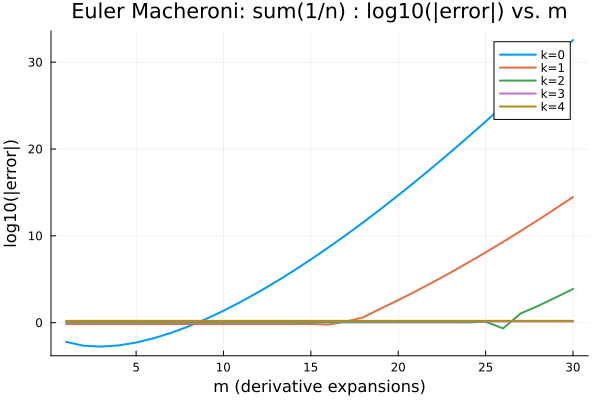

26	2.1866535773324673e+00	1.6094435773324673e+00
27	2.1866535773446532e+00	1.6094435773446532e+00
28	2.1866535773079829e+00	1.6094435773079829e+00
29	2.1866535774265818e+00	1.6094435774265818e+00
30	2.1866535770153739e+00	1.6094435770153739e+00


┌ Warning: Analytical integration failed or diverged; setting integral to 0.0.
└ @ Main.Analytictail /Users/sairampatro/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sZmlsZQ==.jl:114
┌ Warning: Analytical integration failed or diverged; setting integral to 0.0.
└ @ Main.Analytictail /Users/sairampatro/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sZmlsZQ==.jl:114
┌ Warning: Analytical integration failed or diverged; setting integral to 0.0.
└ @ Main.Analytictail /Users/sairampatro/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sZmlsZQ==.jl:114
┌ Warning: Analytical integration failed or diverged; setting integral to 0.0.
└ @ Main.Analytictail /Users/sairampatro/Desktop/GIT/Computational-aspects-of-Ramanujan-Summation/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sZmlsZQ==.jl:114


In [6]:
run_example(1/x_, "Euler Macheroni: sum(1/n)", 0.57721, false)

### Example 2: Basel: sum(1/n²) = π²/6


=== run_example: Basel: sum(1/n²) = π²/6

Basel: sum(1/n²) = π²/6 => alt=false, k=0 => exact=1.6449340668482264
m	Approx	Error
 1	1.6666666666666667e+00	2.1732599818440335e-02
 2	1.6333333333333333e+00	1.1600733514893102e-02
 3	1.6571428571428573e+00	1.2208790294630845e-02
 4	1.6238095238095238e+00	2.1124543038702592e-02
 5	1.6995670995670995e+00	5.4633032718873098e-02
 6	1.4464535464535464e+00	1.9848052039468000e-01
 7	2.6131202131202129e+00	9.6818614627198651e-01
 8	-4.4790366496248852e+00	6.1239707164731119e+00
 9	5.0492141295237268e+01	4.8847207228389038e+01
10	-4.7863210112900515e+02	4.8027703519585339e+02
11	5.7134910872767923e+03	5.7118461532099445e+03
12	-8.0866762026276323e+04	8.0868406960343171e+04
13	1.3446504046403903e+06	1.3446487597063235e+06
14	-2.5953580663175702e+07	2.5953582308109768e+07
15	5.7562729323746669e+08	5.7562729159253263e+08
16	-1.4540688473854689e+10	1.4540688475499622e+10
17	4.1507395458731201e+11	4.1507395458566705e+11
18	-1.3296581250501020e+13	1.32965

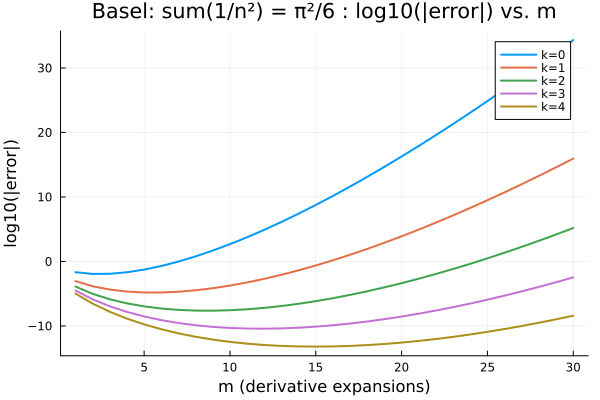

In [7]:
run_example(1/x_^2, "Basel: sum(1/n²) = π²/6", float(pi^2/6), false)

### Example 3: Zeta(3): sum(1/n³) ≈ 1.20206


=== run_example: Zeta(3): sum(1/n³) ≈ 1.20206

Zeta(3): sum(1/n³) ≈ 1.20206 => alt=false, k=0 => exact=1.202056903159594
m	Approx	Error
 1	1.2500000000000000e+00	4.7943096840405985e-02
 2	1.1666666666666667e+00	3.5390236492927274e-02
 3	1.2500000000000000e+00	4.7943096840405985e-02
 4	1.1000000000000001e+00	1.0205690315959393e-01
 5	1.5166666666666666e+00	3.1460976350707259e-01
 6	-1.2857142857142856e-01	1.3306283317310226e+00
 7	8.6214285714285719e+00	7.4193716682689779e+00
 8	-5.1661904761904765e+01	5.2863961665064359e+01
 9	4.7056428571428569e+02	4.6936222881112610e+02
10	-5.0852402597402597e+03	5.0864423166434190e+03
11	6.6124176406926417e+04	6.6122974350023258e+04
12	-1.0161289875124876e+06	1.0161301895693907e+06
13	1.8228352762487512e+07	1.8228351560430609e+07
14	-3.7759599772084582e+08	3.7759599892290270e+08
15	8.9469075477391109e+09	8.9469075465370541e+09
16	-2.4047230260928146e+11	2.4047230261048352e+11
17	7.2777839509611357e+12	7.2777839509599336e+12
18	-2.4638783734317303e+

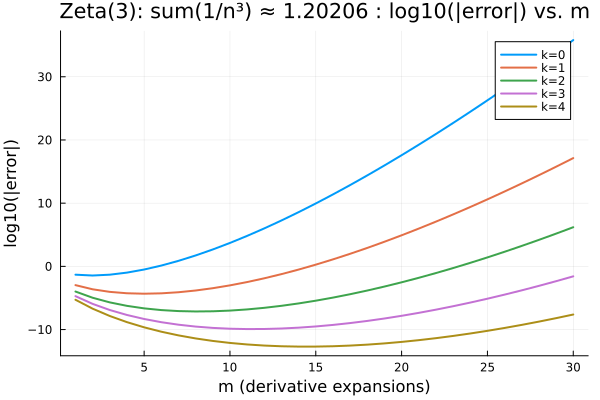

In [8]:
run_example(1/x_^3, "Zeta(3): sum(1/n³) ≈ 1.20206", 1.202056903159594, false)

### Example 4: Zeta(4): sum(1/n⁴) = π⁴/90


=== run_example: Zeta(4): sum(1/n⁴) = π⁴/90

Zeta(4): sum(1/n⁴) = π⁴/90 => alt=false, k=0 => exact=1.0823232337111381
m	Approx	Error
 1	1.1666666666666665e+00	8.4343432955528375e-02
 2	9.9999999999999989e-01	8.2323233711138255e-02
 3	1.2222222222222221e+00	1.3989898851108395e-01
 4	7.2222222222222210e-01	3.6010101148891605e-01
 5	2.3888888888888888e+00	1.3065656551777507e+00
 6	-5.2888888888888888e+00	6.3712121226000269e+00
 7	4.1377777777777780e+01	4.0295454544066644e+01
 8	-3.2032222222222219e+02	3.2140454545593332e+02
 9	3.1611857142857143e+03	3.1601033910520032e+03
10	-3.7581380952380954e+04	3.7582463275614668e+04
11	5.3209395238095243e+05	5.3209287005771871e+05
12	-8.8474334682539683e+06	8.8474345505772028e+06
13	1.7076772953174603e+08	1.7076772844942281e+08
14	-3.7874757753015871e+09	3.7874757763839102e+09
15	9.5673895376271301e+10	9.5673895375188980e+10
16	-2.7310771530699619e+12	2.7310771530710444e+12
17	8.7487997889775047e+13	8.7487997889773969e+13
18	-3.1256098718359240e+15	

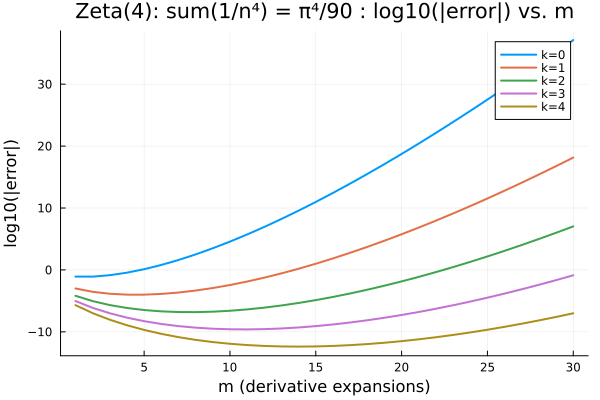

In [9]:
run_example(1/x_^4, "Zeta(4): sum(1/n⁴) = π⁴/90", float(pi^4/90), false)

### Example 5: Zeta(5): sum(1/n⁵) ≈ 1.03693


=== run_example: Zeta(5): sum(1/n⁵) ≈ 1.03693

Zeta(5): sum(1/n⁵) ≈ 1.03693 => alt=false, k=0 => exact=1.03692775514337
m	Approx	Error
 1	1.1666666666666667e+00	1.2973891152329675e-01
 2	8.7500000000000000e-01	1.6192775514336999e-01
 3	1.3750000000000000e+00	3.3807224485663001e-01
 4	-1.7272337110188889e-77	1.0369277551433700e+00
 5	5.4166666666666670e+00	4.3797389115232974e+00
 6	-2.3375000000000000e+01	2.4411927755143370e+01
 7	1.7495833333333334e+02	1.7392140557818996e+02
 8	-1.5431166666666666e+03	1.5441535944218099e+03
 9	1.6734799999999999e+04	1.6733763072244856e+04
10	-2.1753495833333334e+05	2.1753599526108848e+05
11	3.3429358750000005e+06	3.3429348380722455e+06
12	-5.9968874214285716e+07	5.9968875251213469e+07
13	1.2422410575357144e+09	1.2422410564987867e+09
14	-2.9434146104922623e+10	2.9434146105959549e+10
15	7.9112216589555359e+11	7.9112216589451660e+11
16	-2.3942949508008988e+13	2.3942949508010023e+13
17	8.1058349463830725e+14	8.1058349463830625e+14
18	-3.0517120735187260e+

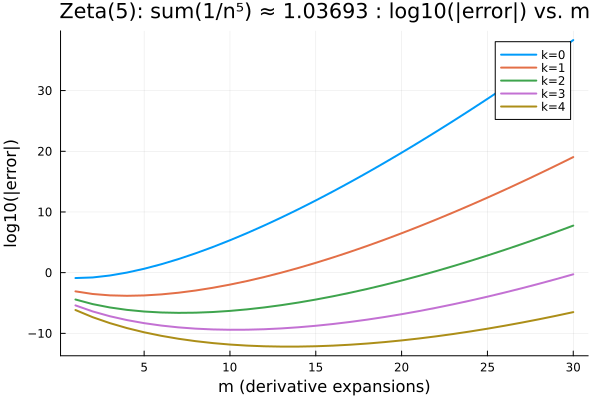

In [10]:
run_example(1/x_^5, "Zeta(5): sum(1/n⁵) ≈ 1.03693", zeta5_approx, false)

### Example 6: Zeta(6): sum(1/n⁶) = π⁶/945


=== run_example: Zeta(6): sum(1/n⁶) = π⁶/945

Zeta(6): sum(1/n⁶) = π⁶/945 => alt=false, k=0 => exact=1.017343061984449
m	Approx	Error
 1	1.2000000000000000e+00	1.8265693801555094e-01
 2	7.3333333333333328e-01	2.8400972865111573e-01
 3	1.7333333333333334e+00	7.1599027134888438e-01
 4	-1.5666666666666667e+00	2.5840097286511154e+00
 5	1.3600000000000000e+01	1.2582656938015550e+01
 6	-7.8533333333333331e+01	7.9550676395317780e+01
 7	6.3546666666666670e+02	6.3444932360468226e+02
 8	-6.2368333333333330e+03	6.2378506763953174e+03
 9	7.4186000000000000e+04	7.4184982656938009e+04
10	-1.0503088399999999e+06	1.0503098573430618e+06
11	1.7464139493333332e+07	1.7464138475990269e+07
12	-3.3708199700666660e+08	3.3708199802400964e+08
13	7.4761775934933329e+09	7.4761775924759893e+09
14	-1.8885270024623999e+11	1.8885270024725732e+11
15	5.3909302213569980e+12	5.3909302213559805e+12
16	-1.7269438583075569e+14	1.7269438583075672e+14
17	6.1697065896812480e+15	6.1697065896812470e+15
18	-2.4445192724892330e+1

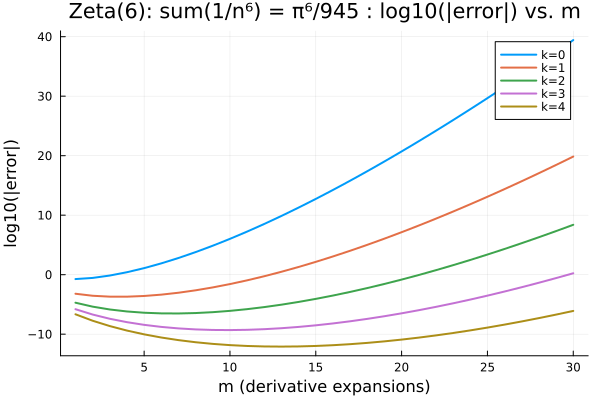

In [11]:
run_example(1/x_^6, "Zeta(6): sum(1/n⁶) = π⁶/945", float(pi^6/945), false)

### Example 7: sum(e⁻ⁿ): 1/(e-1)


=== run_example: sum(e⁻ⁿ): 1/(e-1)

sum(e⁻ⁿ): 1/(e-1) => alt=false, k=0 => exact=0.5819767068693265
m	Approx	Error
 1	5.8247578185478366e-01	4.9907498545720408e-04
 2	5.8196483818649003e-01	1.1868682836424505e-05
 3	5.8197700351192561e-01	2.9664259915129776e-07
 4	5.8197669937878971e-01	7.4905367464239703e-09
 5	5.8197670705891935e-01	1.8959289693754044e-10
 6	5.8197670686452485e-01	4.8016035592013395e-12
 7	5.8197670686944802e-01	1.2156942119645464e-13
 8	5.8197670686932335e-01	3.1086244689504383e-15
 9	5.8197670686932657e-01	1.1102230246251565e-16
10	5.8197670686932645e-01	0.0000000000000000e+00
11	5.8197670686932645e-01	0.0000000000000000e+00
12	5.8197670686932645e-01	0.0000000000000000e+00
13	5.8197670686932645e-01	0.0000000000000000e+00
14	5.8197670686932645e-01	0.0000000000000000e+00
15	5.8197670686932645e-01	0.0000000000000000e+00
16	5.8197670686932645e-01	0.0000000000000000e+00
17	5.8197670686932645e-01	0.0000000000000000e+00
18	5.8197670686932645e-01	0.0000000000000000e+00
19

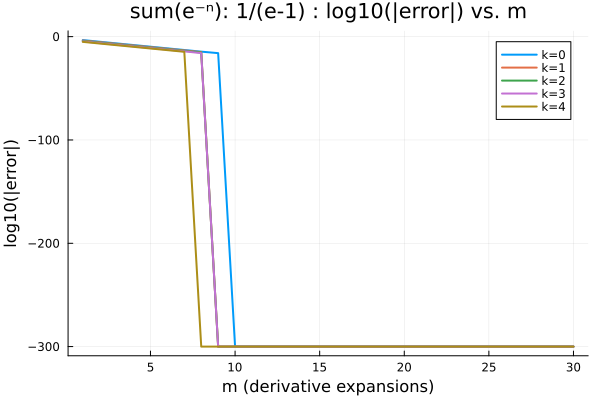

In [12]:
run_example(exp(-x_), "sum(e⁻ⁿ): 1/(e-1)", 1/(exp(1)-1), false)

### Example 8: sum(2⁻ⁿ) = 1


=== run_example: sum(2⁻ⁿ) = 1

sum(2⁻ⁿ) = 1 => alt=false, k=0 => exact=1.0
m	Approx	Error
 1	1.0002286529678128e+00	2.2865296781282574e-04
 2	9.9999738584837594e-01	2.6141516240585361e-06
 3	1.0000000313956272e+00	3.1395627209107602e-08
 4	9.9999999961909847e-01	3.8090153253733661e-10
 5	1.0000000000046321e+00	4.6320725033410781e-12
 6	9.9999999999994360e-01	5.6399329650957952e-14
 7	1.0000000000000007e+00	6.6613381477509392e-16
 8	1.0000000000000000e+00	0.0000000000000000e+00
 9	1.0000000000000000e+00	0.0000000000000000e+00
10	1.0000000000000000e+00	0.0000000000000000e+00
11	1.0000000000000000e+00	0.0000000000000000e+00
12	1.0000000000000000e+00	0.0000000000000000e+00
13	1.0000000000000000e+00	0.0000000000000000e+00
14	1.0000000000000000e+00	0.0000000000000000e+00
15	1.0000000000000000e+00	0.0000000000000000e+00
16	1.0000000000000000e+00	0.0000000000000000e+00
17	1.0000000000000000e+00	0.0000000000000000e+00
18	1.0000000000000000e+00	0.0000000000000000e+00
19	1.0000000000000000e+00	0

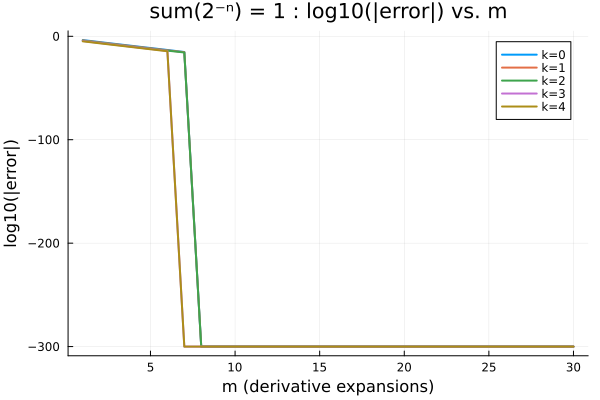

In [13]:
run_example((Sym(2))^(-x_), "sum(2⁻ⁿ) = 1", 1.0, false)

### Example 9: sum(1/(n+1)²) = ζ(2)-1


=== run_example: sum(1/(n+1)²) = ζ(2)-1

sum(1/(n+1)²) = ζ(2)-1 => alt=false, k=0 => exact=0.6449340668482264
m	Approx	Error
 1	6.4583333333333337e-01	8.9926648510696428e-04
 2	6.4479166666666665e-01	1.4240018155975420e-04
 3	6.4497767857142863e-01	4.3611723202219288e-05
 4	6.4491257440476191e-01	2.1492443464499189e-05
 5	6.4494956540854975e-01	1.5498560323345956e-05
 6	6.4491866775802320e-01	1.5399090203205290e-05
 7	6.4495427159916907e-01	2.0204750942665051e-05
 8	6.4490016273638562e-01	3.3904111840787898e-05
 9	6.4500501193748294e-01	7.0945089256535532e-05
10	6.4475270583738897e-01	1.8136101083743306e-04
11	6.4549086444348969e-01	5.5679759526328088e-04
12	6.4291057182779132e-01	2.0234950204350843e-03
13	6.5353150237033986e-01	8.5974355221134502e-03
14	6.0268458468928643e-01	4.2249482158939977e-02
15	8.8281750884957433e-01	2.3788344200134792e-01
16	-8.7695325601402807e-01	1.5218873228622545e+00
17	1.1626478477368334e+01	1.0981544410520108e+01
18	-8.8138943615151916e+01	8.87838776820

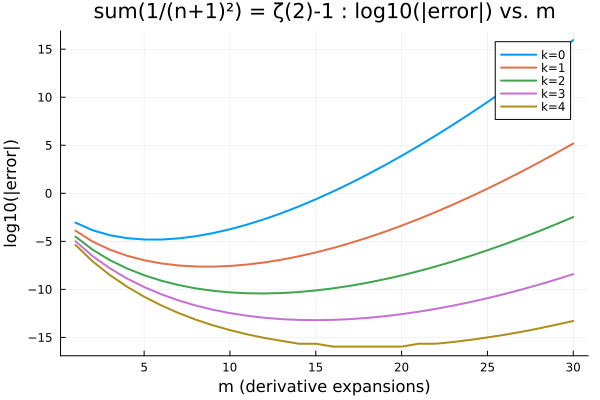

In [14]:
run_example(1/(x_+1)^2, "sum(1/(n+1)²) = ζ(2)-1", float(pi^2/6 - 1.0), false)

### Example 10: sum(1/[n(n+1)]) = 1


=== run_example: sum(1/[n(n+1)]) = 1

sum(1/[n(n+1)]) = 1 => alt=false, k=0 => exact=1.0
m	Approx	Error
 1	1.0056471805599454e+00	5.6471805599453972e-03
 2	9.9783468055994529e-01	2.1653194400547138e-03
 3	1.0017409305599454e+00	1.7409305599453972e-03
 4	9.9759053993494529e-01	2.4094600650547138e-03
 5	1.0051588993099454e+00	5.1588993099453972e-03
 6	9.8407125282557029e-01	1.5928747174429714e-02
 7	1.0673994998958829e+00	6.7399499895882897e-02
 8	6.2414645958216208e-01	3.7585354041783792e-01
 9	3.6780891399410489e+00	2.6780891399410489e+00
10	-2.2778097750661061e+01	2.3778097750661061e+01
11	2.5868198007154734e+02	2.5768198007154734e+02
12	-3.3488283513021147e+03	3.3498283513021147e+03
13	5.1478754165036560e+04	5.1477754165036560e+04
14	-9.2345806605361553e+05	9.2345906605361553e+05
15	1.9129237711958934e+07	1.9129236711958934e+07
16	-4.5325562989968526e+08	4.5325563089968526e+08
17	1.2182469165281487e+10	1.2182469164281487e+10
18	-3.6869684208162970e+11	3.6869684208262970e+11
19	1.248

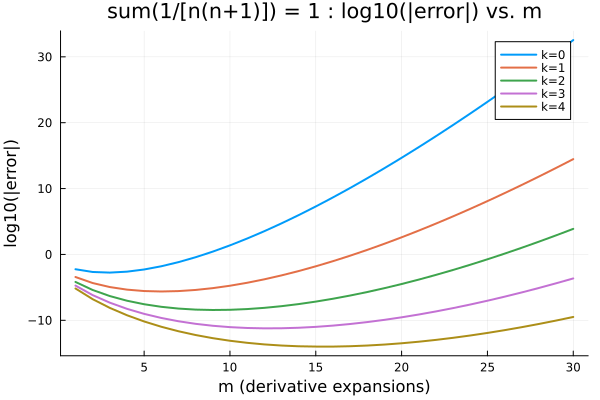

In [15]:
run_example(1/(x_*(x_+1)), "sum(1/[n(n+1)]) = 1", 1.0, false)

### Example 11: sum[(-1)^(n+1)/n] = ln2


=== run_example: sum[(-1)^(n+1)/n] = ln2

sum[(-1)^(n+1)/n] = ln2 => alt=true, k=0 => exact=0.6931471805599453
m	Approx	Error
 1	0.0000000000000000e+00	6.9314718055994529e-01
 2	0.0000000000000000e+00	6.9314718055994529e-01
 3	-9.8370055013617008e-01	1.6768477306961154e+00
 4	-9.8370055013617008e-01	1.6768477306961154e+00
 5	-1.0456555130722145e+00	1.7388026936321599e+00
 6	-1.0456555130722145e+00	1.7388026936321599e+00
 7	-3.6197803044100283e+00	4.3129274849699737e+00
 8	-3.6197803044100327e+00	4.3129274849699781e+00
 9	1.1508563991255887e+01	1.0815416810695941e+01
10	1.1508563991255887e+01	1.0815416810695941e+01
11	-1.6155741372709730e+02	1.6225056090765725e+02
12	-1.6155741372709852e+02	1.6225056090765847e+02
13	2.5686682521302732e+03	2.5679751049497131e+03
14	2.5686682521302637e+03	2.5679751049497036e+03
15	-5.5529636389505766e+04	5.5530329536686324e+04
16	-5.5529636389505904e+04	5.5530329536686462e+04
17	1.5456156470388430e+06	1.5456149538916624e+06
18	1.5456156470388377e+06	1.54

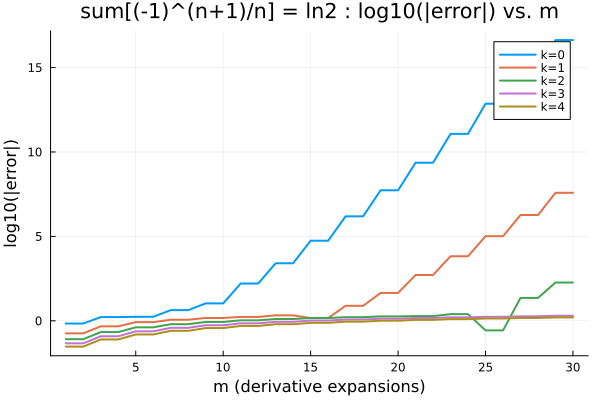

In [16]:
run_example(-cos(pi*x_)/x_, "sum[(-1)^(n+1)/n] = ln2", log(2), true)

### Example 12: sum[(-1)^(n+1)/n²] = π²/12


=== run_example: sum[(-1)^(n+1)/n²] = π²/12

sum[(-1)^(n+1)/n²] = π²/12 => alt=true, k=0 => exact=0.8224670334241132
m	Approx	Error
 1	-5.0000000000000000e-01	1.3224670334241133e+00
 2	-5.0000000000000000e-01	1.3224670334241133e+00
 3	-1.9674011002723402e+00	2.7898681336964533e+00
 4	-1.9674011002723402e+00	2.7898681336964533e+00
 5	8.4349117440024968e-01	2.1024140976136474e-02
 6	8.4349117440024968e-01	2.1024140976136474e-02
 7	-1.6251050575633887e+01	1.7073517609058001e+01
 8	-1.6251050575633926e+01	1.7073517609058040e+01
 9	1.3869523666300577e+02	1.3787276962958165e+02
10	1.3869523666300577e+02	1.3787276962958165e+02
11	-1.9343380813849917e+03	1.9351605484184158e+03
12	-1.9343380813850076e+03	1.9351605484184317e+03
13	3.6292639878000162e+04	3.6291817410966738e+04
14	3.6292639878000024e+04	3.6291817410966600e+04
15	-8.9327637543730892e+05	8.9327719790434232e+05
16	-8.9327637543731125e+05	8.9327719790434465e+05
17	2.7927342613499548e+07	2.7927341791032515e+07
18	2.7927342613499448e+0

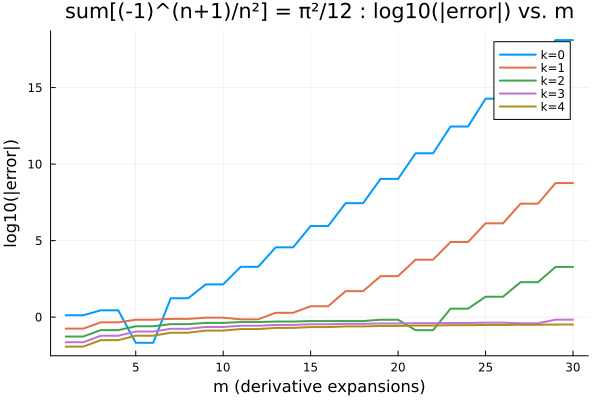

In [17]:
run_example(-cos(pi*x_)/x_^2, "sum[(-1)^(n+1)/n²] = π²/12", float(pi^2/12), true)

### Example 13: sum[(-1)^(n+1)/n³] ≈ 0.90154


=== run_example: sum[(-1)^(n+1)/n³] ≈ 0.90154

sum[(-1)^(n+1)/n³] ≈ 0.90154 => alt=true, k=0 => exact=0.9015426773696955
m	Approx	Error
 1	-1.0000000000000000e+00	1.9015426773696955e+00
 2	-1.0000000000000000e+00	1.9015426773696955e+00
 3	-2.2011016504085097e+00	3.1026443277782052e+00
 4	-2.2011016504085097e+00	3.1026443277782052e+00
 5	5.8848411626897326e+00	4.9832984853200371e+00
 6	5.8848411626897326e+00	4.9832984853200371e+00
 7	-6.0095374501708264e+01	6.0996917179077961e+01
 8	-6.0095374501708434e+01	6.0996917179078132e+01
 9	7.1593631111433774e+02	7.1503476843696808e+02
10	7.1593631111433774e+02	7.1503476843696808e+02
11	-1.1906062649855045e+04	1.1906964192532414e+04
12	-1.1906062649855150e+04	1.1906964192532520e+04
13	2.6132196955921964e+05	2.6132106801654227e+05
14	2.6132196955921856e+05	2.6132106801654119e+05
15	-7.3533120768966386e+06	7.3533129784393162e+06
16	-7.3533120768966591e+06	7.3533129784393366e+06
17	2.5854123209137535e+08	2.5854123118983269e+08
18	2.585412320913744

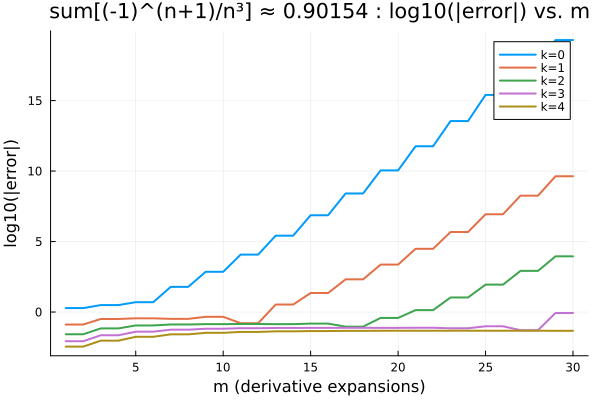

In [18]:
run_example(-cos(pi*x_)/x_^3, "sum[(-1)^(n+1)/n³] ≈ 0.90154", eta3_approx, true)

### Example 14: Catalan: ≈ 0.91597


=== run_example: Catalan: ≈ 0.91597

Catalan: ≈ 0.91597 => alt=true, k=0 => exact=0.915965594177219
m	Approx	Error
 1	-1.5000000000000000e+00	2.4159655941772189e+00
 2	-1.5000000000000000e+00	2.4159655941772189e+00
 3	1.5651977994553210e+00	6.4923220527810199e-01
 4	1.5651977994553210e+00	6.4923220527810199e-01
 5	-2.3595391244663340e+01	2.4511356838840559e+01
 6	-2.3595391244663340e+01	2.4511356838840559e+01
 7	4.0364800199418369e+02	4.0273203640000645e+02
 8	4.0364800199418545e+02	4.0273203640000821e+02
 9	-1.2062198924907345e+04	1.2063114890501522e+04
10	-1.2062198924907345e+04	1.2063114890501522e+04
11	5.4367297069726000e+05	5.4367205473166576e+05
12	5.4367297069726780e+05	5.4367205473167356e+05
13	-3.4592301393801183e+07	3.4592302309766777e+07
14	-3.4592301393800944e+07	3.4592302309766538e+07
15	2.9558226914027343e+09	2.9558226904867687e+09
16	2.9558226914027486e+09	2.9558226904867830e+09
17	-3.2669988717685089e+11	3.2669988717776685e+11
18	-3.2669988717684869e+11	3.2669988717776

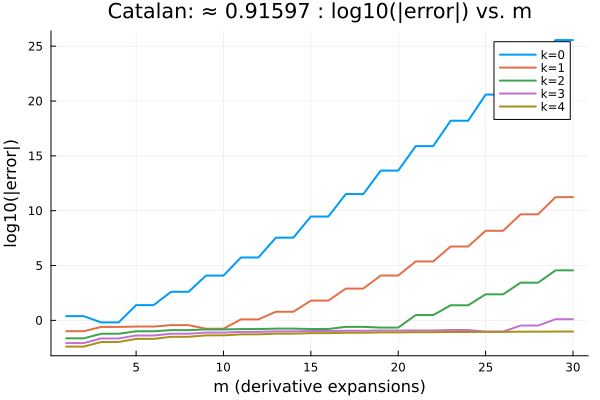

In [19]:
run_example(cos(pi*(x_-1))/(2*x_ - 1)^2, "Catalan: ≈ 0.91597", 0.915965594177219, true)

### Example 15: Arctan(1): π/4


=== run_example: Arctan(1): π/4

Arctan(1): π/4 => alt=true, k=0 => exact=0.7853981633974483
m	Approx	Error
 1	-5.0000000000000000e-01	1.2853981633974483e+00
 2	-5.0000000000000000e-01	1.2853981633974483e+00
 3	-9.6740110027233972e-01	1.7527992636697880e+00
 4	-9.6740110027233972e-01	1.7527992636697880e+00
 5	-1.2869044245103907e+00	2.0723025879078389e+00
 6	-1.2869044245103907e+00	2.0723025879078389e+00
 7	-1.5302146800955294e+00	2.3156128434929775e+00
 8	-1.5302146800955292e+00	2.3156128434929775e+00
 9	-1.7265297053254076e+00	2.5119278687228559e+00
10	-1.7265297053254076e+00	2.5119278687228559e+00
11	-1.8909602009723088e+00	2.6763583643697570e+00
12	-1.8909602009723088e+00	2.6763583643697570e+00
13	-2.0323604484450564e+00	2.8177586118425046e+00
14	-2.0323604484450564e+00	2.8177586118425046e+00
15	-2.1563590358641402e+00	2.9417571992615885e+00
16	-2.1563590358641402e+00	2.9417571992615885e+00
17	-2.2667525209024073e+00	3.0521506842998556e+00
18	-2.2667525209024073e+00	3.052150684299

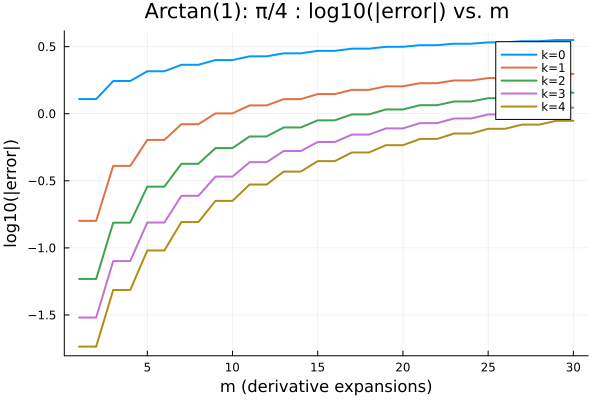

In [20]:
run_example(cos(pi*(x_-1))/(2*x_ - 1), "Arctan(1): π/4", float(pi/4), true)

### Example 16: sum[(-1)^n/√n] ≈ -0.60490


=== run_example: sum[(-1)^n/√n] ≈ -0.60490

sum[(-1)^n/√n] ≈ -0.60490 => alt=true, k=0 => exact=-0.6048986434
m	Approx	Error
 1	-2.5000000000000000e-01	3.5489864339999999e-01
 2	-2.5000000000000000e-01	3.5489864339999999e-01
 3	2.8872527506808504e-01	8.9362391846808498e-01
 4	2.8872527506808504e-01	8.9362391846808498e-01
 5	6.5538733783717096e-01	1.2602859812371709e+00
 6	6.5538733783717096e-01	1.2602859812371709e+00
 7	1.5143870692259080e+00	2.1192857126259081e+00
 8	1.5143870692259083e+00	2.1192857126259081e+00
 9	-7.9536335945340220e-01	1.9046471605340221e-01
10	-7.9536335945340220e-01	1.9046471605340221e-01
11	2.7681743768792582e+01	2.8286642412192581e+01
12	2.7681743768792774e+01	2.8286642412192773e+01
13	-3.8492350044504627e+02	3.8431860180164625e+02
14	-3.8492350044504497e+02	3.8431860180164495e+02
15	7.8572177589572357e+03	7.8578226576006355e+03
16	7.8572177589572548e+03	7.8578226576006546e+03
17	-2.0659429564104247e+05	2.0659369074239908e+05
18	-2.0659429564104177e+05	2.06593

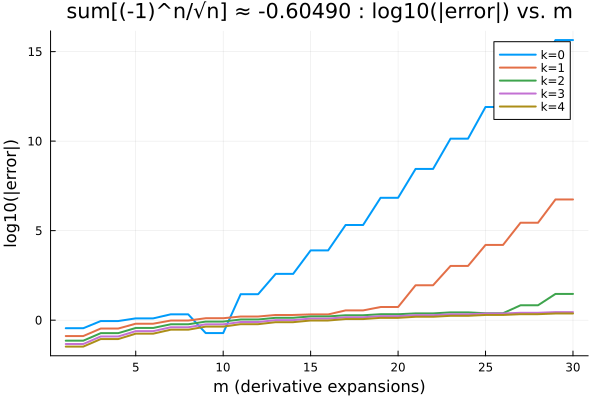

In [21]:
run_example(cos(pi*x_)/sqrt(x_), "sum[(-1)^n/√n] ≈ -0.60490", alt_sqrt_approx, true)